# IQC and IQC:AIL

## Imports

In [23]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger

from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn import datasets
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import pandas as pd

#C: 
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix


## Base de Dados

In [2]:
breast_cancer=fetch_ucirepo(id=17)

In [3]:
print(breast_cancer.metadata.num_instances)
X = breast_cancer.data.features
y = breast_cancer.data.targets
print(breast_cancer.variables)

569
                  name     role         type demographic description units  \
0                   ID       ID  Categorical        None        None  None   
1            Diagnosis   Target  Categorical        None        None  None   
2              radius1  Feature   Continuous        None        None  None   
3             texture1  Feature   Continuous        None        None  None   
4           perimeter1  Feature   Continuous        None        None  None   
5                area1  Feature   Continuous        None        None  None   
6          smoothness1  Feature   Continuous        None        None  None   
7         compactness1  Feature   Continuous        None        None  None   
8           concavity1  Feature   Continuous        None        None  None   
9      concave_points1  Feature   Continuous        None        None  None   
10           symmetry1  Feature   Continuous        None        None  None   
11  fractal_dimension1  Feature   Continuous        None    


Caio: Como temos 19 parâmetros, precisamos $log_2(31)$ qubits(ou o inteiro mais 1), o que resulta em 5 qubits ambientes.

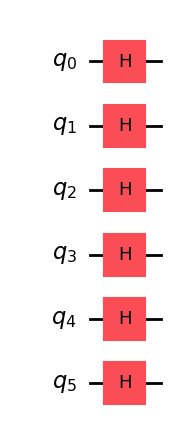

In [37]:
# Criando o circuito
Nenv = 5 #Numero de qubits de entrada. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
Ntarget = 1 #Qubits alvo

Nqubits = Nenv + Ntarget
qc = QuantumCircuit(Nqubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,int(Nqubits)))
qc.draw('mpl')


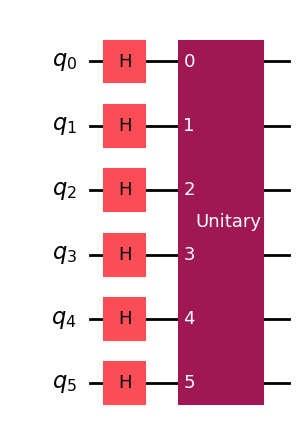

In [38]:
#Printando o circuito

#C: Coloquei tudo em termos dos qubits para facilitar.
x=np.random.rand(2**Nenv)
w=np.random.rand(2**Nenv)

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

sigmaE=np.diag(x)*w.T
#C: Note que temos 32 parâmetros(5 qubits), o que é maior que os 31 parâmetros do dataset. 
#C: O que podemos fazer para deixar esses dois parâmetros iguais é zerar o último parâmetro, ou seja:
sigmaE[31,31] = 0 

#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(Nqubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

## Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

### Statevector

In [39]:
#Estado completo
sv = Statevector(qc)
sv.draw("latex")

<IPython.core.display.Latex object>

### Matriz Densidade

In [59]:
# Ao traçar fora o ambiente

rho_res = partial_trace(DensityMatrix.from_instruction(qc), [1,2,3,4,5]).data 
# C: para generalizar tem q substituir esse [] com o os qubits ancilla
print("Após o traco parcial")

print(rho_res)

Após o traco parcial
[[0.5       +5.11946713e-18j 0.37859647-2.78025758e-02j]
 [0.37859647+2.78025758e-02j 0.5       -4.66545747e-18j]]


### Toy Example

In [60]:
#Toy example
x=np.random.rand(2)
w=np.random.rand(2)

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

sigmaE=np.diag(x)*w.T

#Operador Unitário
#Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
#U=expMatrix(-1j*Hint*(t/hbar))
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
print(len(U))
print (U@np.ones(len(U)))

4
[[1.12039016+3.18235537e-01j 1.15413187+6.08446142e-01j
  0.80215462-2.77555756e-17j 0.54568573+0.00000000e+00j]]


## IQC

In [3]:
def IQC(x,w):
  n = len(x)

  #from sympy.physics.matrices import msigma(indice)

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

## IQC:AIL

In [ ]:
def IQC_AIL(x,w):
  n = len(x)
  norma_x=np.linalg.norm(x)+1e-16 #To avoid zero division

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T #No fim, é uma matriz composta apenas por pesos

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE